In [45]:
# load necessary libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import defaultdict
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader, Sampler
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import umap
from tqdm import tqdm

# load the dictionary terms
groups_dictionary = pd.read_csv("../01_data/dictionary/groups_dictionary_cl_augmentations.csv")

# load the ground truth data with augmentations
with open("../01_data/annotations/annotations_augmentations.json") as f:
    gt_augmentations = json.load(f)

In [46]:
# create a single list of all dictionary entries paired with their category
mention_list = []
category_list = []
categories = groups_dictionary.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dictionary[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)

category_list = [cat for cat in category_list]

df = pd.DataFrame({'mention': mention_list, 'category': category_list})

mention_list = df["mention"].to_list()
category_list = df["category"].to_list()

In [132]:
class UnbalancedDataset(Dataset):
    def __init__(self, tokenizer, cat2id, mentions, labels, max_len=64):
        self.dataset = []
        self.max_len = max_len
        mask_token = tokenizer.mask_token

        for mention, label in zip(mentions, labels):
            text = f"Social group of {mention} is: {mask_token}."
            encoding = tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=self.max_len,
                return_tensors="pt"
            )

            self.dataset.append({
                "input_ids": encoding["input_ids"].squeeze(0),
                "attention_mask": encoding["attention_mask"].squeeze(0),
                "label_id": torch.tensor(cat2id[label])
            })

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        return self.dataset[idx]
    

category_to_indices = defaultdict(list)

for idx, cat in enumerate(category_list):
    category_to_indices[cat].append(idx)

class BalancedDataset(Dataset):
    def __init__(self, mentions, labels):
        self.mentions = mentions
        self.labels = labels
    
    def __len__(self):
        return len(self.mentions)
    
    def __getitem__(self, idx):
        return self.mentions[idx], self.labels[idx]

class BalancedBatchSampler(Sampler):
    def __init__(self, category_to_indices, categories_per_batch, samples_per_category, batches_per_epoch):
        self.category_to_indices = category_to_indices
        self.categories = list(category_to_indices.keys())
        self.categories_per_batch = categories_per_batch
        self.samples_per_category = samples_per_category
        self.batches_per_epoch = batches_per_epoch

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch_indices = []
            selected_cats = random.sample(self.categories, self.categories_per_batch)
            for cat in selected_cats:
                indices = self.category_to_indices[cat]
                chosen = random.sample(indices, k=self.samples_per_category)
                batch_indices.extend(chosen)
            yield batch_indices


def collate_fn(batch, tokenizer, cat2id):
    mentions, labels = zip(*batch)

    mask_token = tokenizer.mask_token

    # Construct masked sentences
    texts = [f"Social group of {m} is: {mask_token}." for m in mentions]

    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )

    label_ids = torch.tensor([cat2id[l] for l in labels])

    return encodings['input_ids'], encodings['attention_mask'], label_ids


class SpanEncoder(nn.Module):
    def __init__(self, tokenizer, model_name="roberta-base", proj_dim=128):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.mask_id = tokenizer.mask_token_id
        hidden_size = self.encoder.config.hidden_size

        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Linear(hidden_size//2, proj_dim)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state

        mask_positions = (input_ids == self.mask_id)
        batch_size = input_ids.size(0)
        h = torch.stack([hidden[i][mask_positions[i]].mean(dim=0) for i in range(batch_size)])

        z = self.projector(h)
        return h, z

def supervised_contrastive_loss(embeddings, labels, temperature=0.1):
    embeddings = F.normalize(embeddings, dim=1)
    sim_matrix = torch.matmul(embeddings, embeddings.T) / temperature

    labels = labels.unsqueeze(1)
    
    mask = torch.eq(labels, labels.T).float()
    mask.fill_diagonal_(0)

    pos_counts = mask.sum(1)
    valid = pos_counts > 0
    pos_counts = torch.clamp(pos_counts, min=1)

    log_prob = F.log_softmax(sim_matrix, dim=1)
    mean_log_prob_pos = (mask * log_prob).sum(1) / pos_counts
    loss = -mean_log_prob_pos[valid].mean()
    return loss

In [123]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# UNBALANCED
dataset = UnbalancedDataset(tokenizer, cat2id, mention_list, category_list)
dataloader = DataLoader(
    dataset=dataset,
    batch_size=32,
    drop_last=True
)

In [133]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# BALANCED
dataset = BalancedDataset(mention_list, category_list)
batch_sampler = BalancedBatchSampler(
    category_to_indices,
    categories_per_batch=45,
    samples_per_category=4,
    batches_per_epoch=4
)

dataloader = DataLoader(
    dataset,
    batch_sampler=batch_sampler,
    collate_fn=lambda b: collate_fn(b, tokenizer, cat2id)
)

In [122]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SpanEncoder(tokenizer).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

for epoch in range(20):
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Training")
    for batch in progress_bar:

        # extract all batch data
        input_ids, attention_mask, batch_labels = [x.to(device) for x in batch]
        
        #input_ids = batch["input_ids"].to(device)
        #attention_mask = batch["attention_mask"].to(device)
        #batch_labels = batch["label_id"].to(device)

        # clear the old gradient
        optimizer.zero_grad()

        # run data through the model and save the outputs, use mps with mixed precision (16 bit floating point for forward pass)
        with torch.autocast(device_type="mps", dtype=torch.float16):
            _, z = model(input_ids, attention_mask)
            # calculate the loss and add to total loss
            loss = supervised_contrastive_loss(z, batch_labels)
            total_loss += loss.item()

        # run backpropagation, cap gradients to prevent explosion
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)

        # update parameters and the progress bar
        optimizer.step()
        progress_bar.set_postfix(loss=loss.item())

    # calculate average batch loss and print it
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}, Average Batch Loss: {avg_loss:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Training: 100%|██████████| 4/4 [00:04<00:00,  1.17s/it, loss=5.09]


Epoch 1, Average Batch Loss: 5.1405


Training: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s, loss=4.81]


Epoch 2, Average Batch Loss: 4.9049


Training: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s, loss=4.52]


...

Epoch 18, Average Batch Loss: 3.3816


Training: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s, loss=3.37]


Epoch 19, Average Batch Loss: 3.3665


Training: 100%|██████████| 4/4 [00:03<00:00,  1.13it/s, loss=3.36]

Epoch 20, Average Batch Loss: 3.3638


In [125]:
model.eval()

with torch.no_grad():
    all_embeddings = []

    for batch in dataloader:
        #input_ids, attention_mask, batch_labels = [x.to(device) for x in batch]
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        batch_labels = batch["label_id"].to(device)
        h, z = model(input_ids, attention_mask)
        all_embeddings.append(z.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
labels_np = np.array([cat2id[cat] for cat in category_list])

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


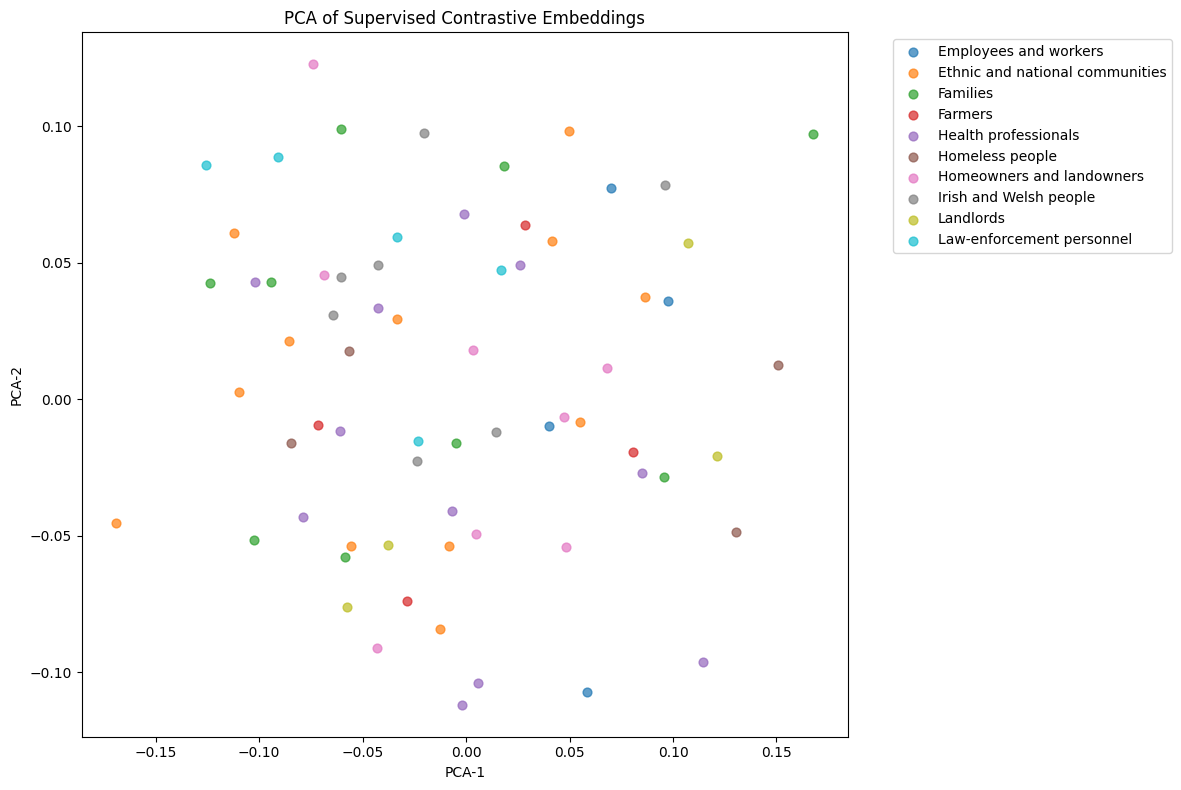

In [128]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings)


plt.figure(figsize=(12, 8))
categories = list(cat2id.keys())
num_classes = len(categories)

for c in range(10, 20):
    idx = np.where(labels_np == c)[0]
    if len(idx) == 0:
        continue
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        label=categories[c],
        alpha=0.7,
        s=40
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("PCA of Supervised Contrastive Embeddings")
plt.tight_layout()
plt.show()

In [127]:
dbscan = DBSCAN(eps=.1, min_samples=3, metric='cosine') 
labels = dbscan.fit_predict(all_embeddings)

cluster_dict = defaultdict(list)

for mention, label in zip(mention_list, labels):
    cluster_dict[label].append(mention)

for cluster_id, mentions in cluster_dict.items():
    print(f"Cluster {cluster_id} ({len(mentions)} mentions):")
    for mention in mentions:
        print(f"  - {mention}")
    print()

Cluster 0 (359 mentions):
  - adults
  - middle-aged people
  - grown-ups
  - persons of mature age
  - therapists
  - caregivers
  - care staff
  - care workers
  - children
  - kids
  - child
  - children at risk
  - pre school children
  - children of working families
  - civil servants
  - public servants
  - public employees
  - civil employees
  - consumers
  - customers
  - purchasers
  - shoppers
  - crime victims
  - victims of crime
  - victims of violence
  - victims of abuse
  - victims of rape
  - victims of violent crime
  - victims
  - offenders
  - criminals
  - yobs
  - prisoners
  - drug traffickers and barons
  - foreign criminals
  - foreign national offenders
  - people smugglers
  - sex offenders
  - terrorist offenders
  - tax avoiders
  - tax evaders
  - teachers
  - educators
  - child-minders
  - headteachers
  - education-professionals
  - principals
  - old people
  - older people
  - pensioners
  - senior citizens
  - elderly
  - retired people
  - retirees